# BSD10k Confidence 5-Class Classification Linear Model

이 노트북은 VS Code/Jupyter에서 로컬 `data` 폴더의 BSD10k 데이터를 사용해 **5개 confidence class**를 분류합니다.

- Metadata: `data/metadata/BSD10k_metadata.csv`
- CLAP audio embedding: 512차원
- CLAP text embedding: 512차원
- 23개 class one-hot
- 출력: confidence 5-class classification

confidence는 audio/text와 class label의 매핑 신뢰도를 나타내므로, 모든 입력 조합은 class one-hot을 함께 사용합니다.

실험 구조는 아래 규칙을 따릅니다.

`경로 검증 -> 로컬 data 사용 -> tqdm 로딩 -> 고정 return 구조 -> dropout sweep -> summary/graph는 고정 key만 사용`

## 1. 설정

아래 경로와 컬럼명은 본인 데이터셋에 맞게 수정하세요.

특히 `SOUND_ID_COL`, `CLASS_COL`, `CONFIDENCE_COL`은 metadata CSV의 실제 컬럼명과 반드시 일치해야 합니다.

In [25]:
# =========================
# 1. 설정
# =========================
import os
import glob
import random
import json
from pathlib import Path

import numpy as np
import pandas as pd
from tqdm.auto import tqdm

import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report, mean_absolute_error, mean_squared_error

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

# -------------------------
# Reproducibility
# -------------------------
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)
torch.backends.cudnn.deterministic = False
torch.backends.cudnn.benchmark = True

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("DEVICE:", DEVICE)
if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

# -------------------------
# VS Code 로컬 프로젝트 경로 자동 탐색
# -------------------------
def find_project_root(start=None):
    start = Path.cwd() if start is None else Path(start)
    for candidate in [start, *start.parents]:
        if (candidate / "data" / "metadata" / "BSD10k_metadata.csv").exists():
            return candidate
    raise FileNotFoundError(
        "data/metadata/BSD10k_metadata.csv를 찾지 못했습니다. "
        "VS Code에서 Dcase baseline 폴더를 작업 폴더로 열었는지 확인하세요."
    )

PROJECT_ROOT = find_project_root()
DATA_DIR = PROJECT_ROOT / "data"

METADATA_CSV = str(DATA_DIR / "metadata" / "BSD10k_metadata.csv")
AUDIO_EMB_DIR = str(DATA_DIR / "features" / "clap_audio_embeddings")
TEXT_EMB_DIR = str(DATA_DIR / "features" / "clap_text_embeddings")

# -------------------------
# Metadata 컬럼명
# -------------------------
SOUND_ID_COL = "sound_id"
CLASS_COL = "class"
CONFIDENCE_COL = "confidence"

# confidence label이 1~5면 True, 0~4면 False
CONFIDENCE_LABEL_STARTS_AT_1 = True

# -------------------------
# 학습 설정
# -------------------------
BATCH_SIZE = 128
EPOCHS = 30
LR = 1e-3
WEIGHT_DECAY = 1e-4
DROPOUT_VALUES = [0.8, 0.7, 0.6, 0.5]
DROPOUT = DROPOUT_VALUES[0]
VAL_SIZE = 0.2
NUM_WORKERS = 0  # Windows/VS Code 노트북에서는 0이 가장 안정적입니다.

# 결과 저장 경로
OUTPUT_DIR = str(PROJECT_ROOT / "outputs" / "confidence_mlp_outputs")
os.makedirs(OUTPUT_DIR, exist_ok=True)

DEVICE: cuda
GPU: NVIDIA GeForce RTX 3060


## 2. 경로 검증

학습 전에 metadata, audio embedding, text embedding 경로를 반드시 검증합니다.

경로가 틀리면 여기서 중단됩니다.

In [26]:
# =========================
# 2. 경로 검증
# =========================
assert os.path.exists(METADATA_CSV), f"METADATA_CSV not found: {METADATA_CSV}"
assert os.path.exists(AUDIO_EMB_DIR), f"AUDIO_EMB_DIR not found: {AUDIO_EMB_DIR}"
assert os.path.exists(TEXT_EMB_DIR), f"TEXT_EMB_DIR not found: {TEXT_EMB_DIR}"

print("PROJECT_ROOT:", PROJECT_ROOT)
print("METADATA_CSV:", METADATA_CSV)
print("AUDIO_EMB_DIR:", AUDIO_EMB_DIR)
print("TEXT_EMB_DIR:", TEXT_EMB_DIR)
print("audio npy count:", len(glob.glob(os.path.join(AUDIO_EMB_DIR, "*.npy"))))
print("text npy count:", len(glob.glob(os.path.join(TEXT_EMB_DIR, "*.npy"))))
print("OUTPUT_DIR:", OUTPUT_DIR)

PROJECT_ROOT: c:\Users\solok\Desktop\Dcase baseline
METADATA_CSV: c:\Users\solok\Desktop\Dcase baseline\data\metadata\BSD10k_metadata.csv
AUDIO_EMB_DIR: c:\Users\solok\Desktop\Dcase baseline\data\features\clap_audio_embeddings
TEXT_EMB_DIR: c:\Users\solok\Desktop\Dcase baseline\data\features\clap_text_embeddings
audio npy count: 10956
text npy count: 10956
OUTPUT_DIR: c:\Users\solok\Desktop\Dcase baseline\outputs\confidence_mlp_outputs


## 3. 로컬 feature 사용

VS Code에서는 Google Drive 마운트나 임시 런타임 복사가 필요 없습니다.

이후 모든 실험은 `data/features/clap_audio_embeddings`, `data/features/clap_text_embeddings`에서 직접 읽습니다.

In [27]:
# =========================
# 3. 로컬 feature 사용
# =========================
# Colab 전용 Drive 복사 단계는 제거했습니다.
# VS Code에서는 이미 PROJECT_ROOT/data 아래에 있는 embedding을 직접 사용합니다.

assert Path(AUDIO_EMB_DIR).exists()
assert Path(TEXT_EMB_DIR).exists()
print("Using local audio embeddings:", AUDIO_EMB_DIR)
print("Using local text embeddings:", TEXT_EMB_DIR)

Using local audio embeddings: c:\Users\solok\Desktop\Dcase baseline\data\features\clap_audio_embeddings
Using local text embeddings: c:\Users\solok\Desktop\Dcase baseline\data\features\clap_text_embeddings


## 4. metadata 로드

컬럼명과 label 분포를 확인합니다.

In [28]:
# =========================
# 4. metadata 로드
# =========================
df = pd.read_csv(METADATA_CSV)
print("metadata shape:", df.shape)
print("columns:", list(df.columns))

required_cols = [SOUND_ID_COL, CLASS_COL, CONFIDENCE_COL]
for col in required_cols:
    assert col in df.columns, f"필수 컬럼이 없습니다: {col}. 현재 columns={list(df.columns)}"

print("\nclass unique count:", df[CLASS_COL].nunique())
print("confidence unique values:", sorted(df[CONFIDENCE_COL].dropna().unique().tolist()))
display(df.head())

metadata shape: (10956, 10)
columns: ['sound_id', 'class', 'class_idx', 'class_top', 'confidence', 'uploader', 'license', 'title', 'tags', 'description']

class unique count: 23
confidence unique values: [1, 2, 3, 4, 5]


,sound_id,class,class_idx,class_top,confidence,uploader,license,title,tags,description
0,185755,fx-o,11,fx,4,marcgp13,http://creativecommons.org/licenses/by/3.0/,microwave_oven.wav,"campus-upf,UPF-CS13,microwave,heat,bell,noise","A microwave oven operating, including the soun..."
1,358405,is-w,5,is,5,MTG,http://creativecommons.org/licenses/by/3.0/,Sax Alto - F5,"good-sounds,single-note,multisample,sax,neuman...",Recorded in the context of the good-sounds.org...
2,358760,is-w,5,is,4,MTG,http://creativecommons.org/licenses/by/3.0/,Sax Alto - G# Major,"good-sounds,sax,neumann-U87,GsharpMajor,scale,...",Recorded in the context of the good-sounds.org...
3,432206,fx-o,11,fx,4,curesforbrokenhearts,http://creativecommons.org/publicdomain/zero/1.0/,EGG SHAKER,"egg-shaker,shaker,percussion",Large plastic egg shaker
4,80630,sp-s,8,sp,5,tim.kahn,https://creativecommons.org/licenses/by/4.0/,mechanics.wav,"american,english,female,fight,speak,talk,text,...","A request for the user ""asexton"", my girlfrien..."


## 5. embedding 로드

`sound_id`는 문자열로 정규화하고, audio/text embedding이 둘 다 있는 샘플만 사용합니다.

In [29]:
# =========================
# 5. embedding 로드
# =========================
def normalize_sound_id(x):
    s = str(x).strip()
    if s.endswith(".0"):
        s = s[:-2]
    return s

def find_npy_path(emb_dir, sound_id):
    # 기본: sound_id.npy
    path = os.path.join(emb_dir, f"{sound_id}.npy")
    if os.path.exists(path):
        return path
    return None

def load_embeddings_and_labels(df):
    rows = []
    audio_list = []
    text_list = []
    class_labels = []
    confidence_labels = []

    missing_audio = 0
    missing_text = 0
    invalid_confidence = 0

    for _, row in tqdm(df.iterrows(), total=len(df), desc="load embeddings"):
        sound_id = normalize_sound_id(row[SOUND_ID_COL])
        audio_path = find_npy_path(AUDIO_EMB_DIR, sound_id)
        text_path = find_npy_path(TEXT_EMB_DIR, sound_id)

        if audio_path is None:
            missing_audio += 1
            continue
        if text_path is None:
            missing_text += 1
            continue

        conf = row[CONFIDENCE_COL]
        if pd.isna(conf):
            invalid_confidence += 1
            continue

        try:
            conf = int(conf)
        except Exception:
            invalid_confidence += 1
            continue

        if CONFIDENCE_LABEL_STARTS_AT_1:
            conf = conf - 1

        if conf < 0 or conf > 4:
            invalid_confidence += 1
            continue

        audio = np.load(audio_path).astype(np.float32).reshape(-1)
        text = np.load(text_path).astype(np.float32).reshape(-1)

        audio_list.append(audio)
        text_list.append(text)
        class_labels.append(str(row[CLASS_COL]).strip())
        confidence_labels.append(conf)
        rows.append({
            "sound_id": sound_id,
            "class_label": str(row[CLASS_COL]).strip(),
            "confidence": conf,
        })

    audio_emb = np.stack(audio_list).astype(np.float32)
    text_emb = np.stack(text_list).astype(np.float32)
    y = np.array(confidence_labels, dtype=np.int64)
    used_df = pd.DataFrame(rows)

    print("총 metadata rows:", len(df))
    print("사용 가능 rows:", len(rows))
    print("missing audio:", missing_audio)
    print("missing text:", missing_text)
    print("invalid confidence:", invalid_confidence)
    print("audio_emb shape:", audio_emb.shape)
    print("text_emb shape:", text_emb.shape)
    print("y shape:", y.shape)
    print("confidence distribution:", dict(pd.Series(y).value_counts().sort_index()))

    return used_df, audio_emb, text_emb, np.array(class_labels), y

used_df, audio_emb, text_emb, class_labels, y = load_embeddings_and_labels(df)

load embeddings:   0%|          | 0/10956 [00:00<?, ?it/s]

총 metadata rows: 10956
사용 가능 rows: 10956
missing audio: 0
missing text: 0
invalid confidence: 0
audio_emb shape: (10956, 512)
text_emb shape: (10956, 512)
y shape: (10956,)
confidence distribution: {0: np.int64(106), 1: np.int64(749), 2: np.int64(3280), 3: np.int64(6045), 4: np.int64(776)}


## 6. feature 생성

confidence는 audio/text와 class label의 매핑에 대한 신뢰도이므로 class 정보를 항상 함께 넣습니다.

실험 구성은 아래 3개로 고정합니다.

- `A_audio_class`: audio embedding + class one-hot
- `B_text_class`: text embedding + class one-hot
- `C_audio_text_class`: audio embedding + text embedding + class one-hot

In [30]:
# =========================
# 6. feature 생성
# =========================
class_encoder = LabelEncoder()
class_ids = class_encoder.fit_transform(class_labels)
num_classes = len(class_encoder.classes_)

assert num_classes <= 23, f"class 개수가 23개보다 큽니다: {num_classes}"

class_onehot = np.eye(num_classes, dtype=np.float32)[class_ids]

# class가 23개보다 적게 잡힌 경우에도 항상 23차원으로 맞춤
if class_onehot.shape[1] < 23:
    padded = np.zeros((class_onehot.shape[0], 23), dtype=np.float32)
    padded[:, :class_onehot.shape[1]] = class_onehot
    class_onehot = padded
elif class_onehot.shape[1] > 23:
    raise ValueError(f"class_onehot dimension이 23을 초과했습니다: {class_onehot.shape[1]}")

features = {
    "A_audio_class": np.concatenate([audio_emb, class_onehot], axis=1),
    "B_text_class": np.concatenate([text_emb, class_onehot], axis=1),
    "C_audio_text_class": np.concatenate([audio_emb, text_emb, class_onehot], axis=1),
}

for name, feat in features.items():
    print(name, feat.shape)

print("class_onehot shape:", class_onehot.shape)
print("class mapping:")
for idx, cls in enumerate(class_encoder.classes_):
    print(idx, "->", cls)

A_audio_class (10956, 535)
B_text_class (10956, 535)
C_audio_text_class (10956, 1047)
class_onehot shape: (10956, 23)
class mapping:
0 -> fx-a
1 -> fx-el
2 -> fx-ex
3 -> fx-h
4 -> fx-m
5 -> fx-n
6 -> fx-o
7 -> fx-v
8 -> is-e
9 -> is-k
10 -> is-p
11 -> is-s
12 -> is-w
13 -> m-m
14 -> m-si
15 -> m-sp
16 -> sp-c
17 -> sp-p
18 -> sp-s
19 -> ss-i
20 -> ss-n
21 -> ss-s
22 -> ss-u


## 7. model / dataset / train 함수 정의

간단한 MLP 구조를 사용합니다.

`Linear(input_dim → 512) → GELU → Dropout → Linear(512 → 256) → GELU → Dropout → Linear(256 → 5)`

In [31]:
# =========================
# 7. model/dataset/train 함수 정의
# =========================
class FeatureDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.tensor(X, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.long)

    def __len__(self):
        return len(self.y)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

class SimpleMLP(nn.Module):
    def __init__(self, input_dim, num_outputs=5, dropout=0.3):
        super().__init__()
        self.net = nn.Sequential(
            nn.Dropout(dropout),
            nn.Linear(input_dim, num_outputs),
        )

    def forward(self, x):
        return self.net(x)

def compute_classification_metrics(y_true, y_pred):
    return {
        "acc": accuracy_score(y_true, y_pred),
        "mae": mean_absolute_error(y_true, y_pred),
        "mse": mean_squared_error(y_true, y_pred),
        "precision_macro": precision_score(y_true, y_pred, average="macro", zero_division=0),
        "recall_macro": recall_score(y_true, y_pred, average="macro", zero_division=0),
        "f1_macro": f1_score(y_true, y_pred, average="macro", zero_division=0),
        "precision_weighted": precision_score(y_true, y_pred, average="weighted", zero_division=0),
        "recall_weighted": recall_score(y_true, y_pred, average="weighted", zero_division=0),
        "f1_weighted": f1_score(y_true, y_pred, average="weighted", zero_division=0),
    }

@torch.no_grad()
def evaluate_model(model, loader, criterion):
    model.eval()
    total_loss = 0.0
    all_true = []
    all_pred = []
    all_prob = []

    for xb, yb in loader:
        xb = xb.to(DEVICE)
        yb = yb.to(DEVICE)
        logits = model(xb)
        loss = criterion(logits, yb)
        probs = torch.softmax(logits, dim=1)
        preds = torch.argmax(probs, dim=1)

        total_loss += loss.item() * len(yb)
        all_true.append(yb.cpu().numpy())
        all_pred.append(preds.cpu().numpy())
        all_prob.append(probs.cpu().numpy())

    y_true = np.concatenate(all_true)
    y_pred = np.concatenate(all_pred)
    y_prob = np.concatenate(all_prob)
    metrics = compute_classification_metrics(y_true, y_pred)
    metrics["loss"] = total_loss / len(y_true)
    return metrics, y_true, y_pred, y_prob

def train_one_experiment(exp_name, X, y, dropout):
    print(f"\n===== Experiment: {exp_name} | dropout={dropout} =====")
    print("X shape:", X.shape, "y shape:", y.shape)

    X_train, X_val, y_train, y_val = train_test_split(
        X, y,
        test_size=VAL_SIZE,
        random_state=SEED,
        stratify=y,
    )

    train_ds = FeatureDataset(X_train, y_train)
    val_ds = FeatureDataset(X_val, y_val)

    train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True, num_workers=NUM_WORKERS, pin_memory=True)
    val_loader = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS, pin_memory=True)

    model = SimpleMLP(input_dim=X.shape[1], num_outputs=5, dropout=dropout).to(DEVICE)
    criterion = nn.CrossEntropyLoss()
    optimizer = torch.optim.AdamW(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)

    history = {
        "epoch": [],
        "train_loss": [],
        "val_loss": [],
        "acc": [],
        "mae": [],
        "mse": [],
        "precision_macro": [],
        "recall_macro": [],
        "f1_macro": [],
    }

    best_f1 = -1
    best_state = None
    best_predictions = None

    for epoch in range(1, EPOCHS + 1):
        model.train()
        train_loss = 0.0

        for xb, yb in train_loader:
            xb = xb.to(DEVICE)
            yb = yb.to(DEVICE)

            optimizer.zero_grad()
            logits = model(xb)
            loss = criterion(logits, yb)
            loss.backward()
            optimizer.step()

            train_loss += loss.item() * len(yb)

        train_loss /= len(train_ds)
        val_metrics, y_true, y_pred, y_prob = evaluate_model(model, val_loader, criterion)

        history["epoch"].append(epoch)
        history["train_loss"].append(train_loss)
        history["val_loss"].append(val_metrics["loss"])
        history["acc"].append(val_metrics["acc"])
        history["mae"].append(val_metrics["mae"])
        history["mse"].append(val_metrics["mse"])
        history["precision_macro"].append(val_metrics["precision_macro"])
        history["recall_macro"].append(val_metrics["recall_macro"])
        history["f1_macro"].append(val_metrics["f1_macro"])

        if val_metrics["f1_macro"] > best_f1:
            best_f1 = val_metrics["f1_macro"]
            best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
            best_predictions = {
                "y_true": y_true,
                "y_pred": y_pred,
                "y_prob": y_prob,
            }

        print(
            f"Epoch {epoch:02d}/{EPOCHS} | "
            f"train_loss={train_loss:.4f} | "
            f"val_loss={val_metrics['loss']:.4f} | "
            f"acc={val_metrics['acc']:.4f} | "
            f"mae={val_metrics['mae']:.4f} | "
            f"mse={val_metrics['mse']:.4f} | "
            f"f1={val_metrics['f1_macro']:.4f}"
        )

    model.load_state_dict(best_state)
    final_metrics = compute_classification_metrics(best_predictions["y_true"], best_predictions["y_pred"])

    # 고정 return 구조
    return {
        "metrics": final_metrics,
        "history": history,
        "predictions": {
            "y_true": best_predictions["y_true"],
            "y_pred": best_predictions["y_pred"],
            "y_prob": best_predictions["y_prob"],
        },
        "dropout": dropout,
        "base_experiment": exp_name,
        "model": model,
    }

def run_all_experiments(features, y, dropout_values):
    results = {}
    for dropout in dropout_values:
        for exp_name, X in features.items():
            run_name = f"{exp_name}_dropout_{dropout:.1f}"
            results[run_name] = train_one_experiment(exp_name, X, y, dropout)
    return results

## 8. 전체 실험 실행

함수를 수정했다면 반드시 이 셀을 다시 실행해서 `results`를 재생성하세요.

In [32]:
# =========================
# 8. 전체 실험 실행
# =========================
results = run_all_experiments(features, y, DROPOUT_VALUES)


===== Experiment: A_audio_class | dropout=0.8 =====
X shape: (10956, 535) y shape: (10956,)
Epoch 01/30 | train_loss=1.4643 | val_loss=1.3518 | acc=0.5502 | mae=0.5370 | mse=0.7304 | f1=0.1460
Epoch 02/30 | train_loss=1.2884 | val_loss=1.2231 | acc=0.5561 | mae=0.5297 | mse=0.7194 | f1=0.1586
Epoch 03/30 | train_loss=1.2001 | val_loss=1.1541 | acc=0.5547 | mae=0.5310 | mse=0.7208 | f1=0.1598
Epoch 04/30 | train_loss=1.1512 | val_loss=1.1142 | acc=0.5552 | mae=0.5278 | mse=0.7121 | f1=0.1665
Epoch 05/30 | train_loss=1.1195 | val_loss=1.0891 | acc=0.5566 | mae=0.5251 | mse=0.7067 | f1=0.1732
Epoch 06/30 | train_loss=1.1004 | val_loss=1.0717 | acc=0.5575 | mae=0.5242 | mse=0.7057 | f1=0.1771
Epoch 07/30 | train_loss=1.0850 | val_loss=1.0592 | acc=0.5579 | mae=0.5228 | mse=0.7016 | f1=0.1772
Epoch 08/30 | train_loss=1.0736 | val_loss=1.0498 | acc=0.5575 | mae=0.5233 | mse=0.7021 | f1=0.1808
Epoch 09/30 | train_loss=1.0706 | val_loss=1.0423 | acc=0.5561 | mae=0.5237 | mse=0.7007 | f1=0.188

## 9. summary table

고정된 return 구조만 사용합니다.

In [33]:
# =========================
# 9. summary table
# =========================
summary_rows = []

for exp_name, res in results.items():
    row = {
        "experiment": exp_name,
        "base_experiment": res["base_experiment"],
        "dropout": res["dropout"],
    }
    row.update(res["metrics"])
    summary_rows.append(row)

summary_df = pd.DataFrame(summary_rows)
summary_df = summary_df.sort_values(["f1_macro", "acc", "mae"], ascending=[False, False, True]).reset_index(drop=True)
display(summary_df)

summary_path = os.path.join(OUTPUT_DIR, "summary_metrics_dropout_sweep.csv")
summary_df.to_csv(summary_path, index=False)
print("saved:", summary_path)

,experiment,base_experiment,dropout,acc,mae,mse,precision_macro,recall_macro,f1_macro,precision_weighted,recall_weighted,f1_weighted
0,C_audio_text_class_dropout_0.5,C_audio_text_class,0.5,0.575730,0.487682,0.624544,0.480642,0.271320,0.283398,0.564152,0.575730,0.519078
1,C_audio_text_class_dropout_0.6,C_audio_text_class,0.6,0.578011,0.486770,0.626369,0.484690,0.268361,0.278614,0.567281,0.578011,0.516679
2,B_text_class_dropout_0.5,B_text_class,0.5,0.578923,0.488139,0.635036,0.497094,0.262334,0.269030,0.572530,0.578923,0.511105
3,C_audio_text_class_dropout_0.7,C_audio_text_class,0.7,0.576186,0.490876,0.636861,0.466430,0.261065,0.266139,0.560185,0.576186,0.510697
4,B_text_class_dropout_0.6,B_text_class,0.6,0.577555,0.490876,0.640511,0.491590,0.256221,0.258945,0.570454,0.577555,0.505303
5,A_audio_class_dropout_0.5,A_audio_class,0.5,0.570712,0.500912,0.659672,0.330437,0.253862,0.251480,0.510087,0.570712,0.502177
6,C_audio_text_class_dropout_0.8,C_audio_text_class,0.8,0.570255,0.500912,0.656934,0.484344,0.250327,0.248271,0.561575,0.570255,0.496491
7,A_audio_class_dropout_0.6,A_audio_class,0.6,0.568431,0.501369,0.656478,0.334463,0.248823,0.244577,0.508015,0.568431,0.497281
8,A_audio_class_dropout_0.7,A_audio_class,0.7,0.562500,0.510949,0.674270,0.324530,0.239661,0.230901,0.499518,0.562500,0.484853
9,B_text_class_dropout_0.7,B_text_class,0.7,0.567974,0.504106,0.661040,0.438085,0.238267,0.228194,0.543554,0.567974,0.484928


saved: c:\Users\solok\Desktop\Dcase baseline\outputs\confidence_mlp_outputs\summary_metrics_dropout_sweep.csv


## 10. graph

각 실험별로 loss, accuracy, precision, recall, f1 그래프를 확인합니다.

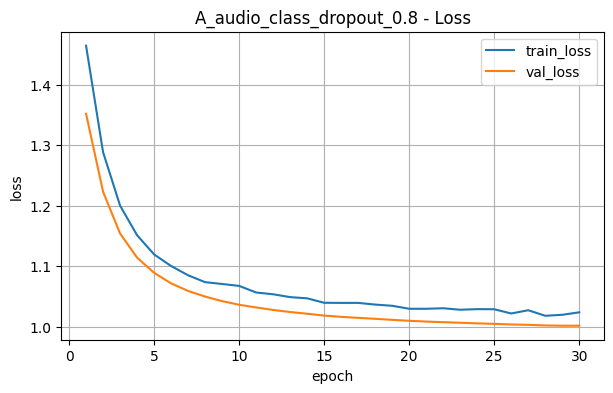

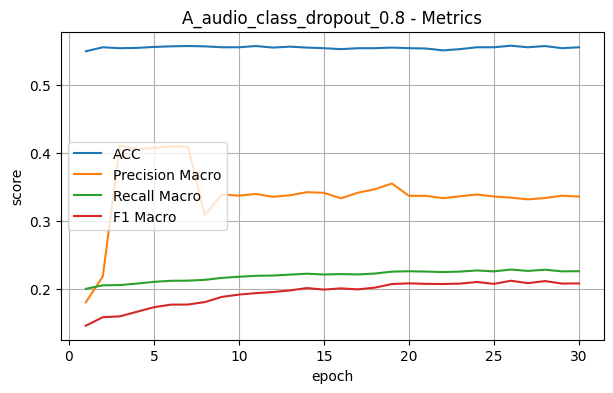

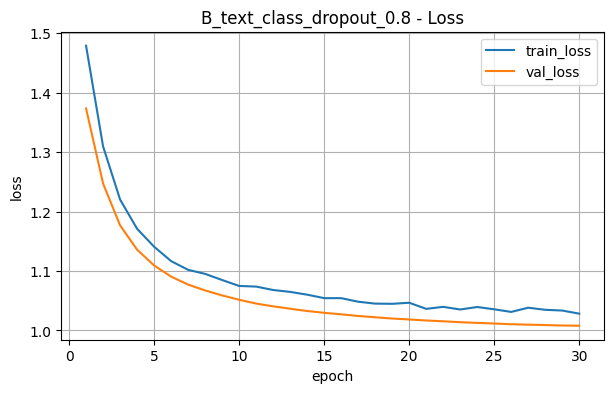

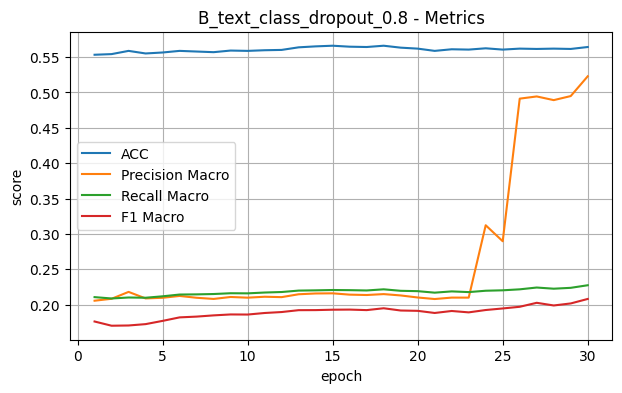

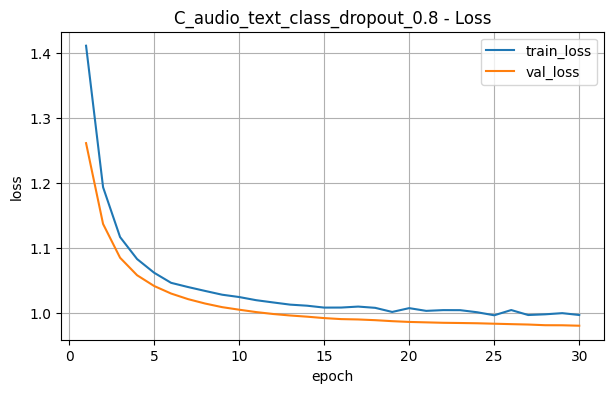

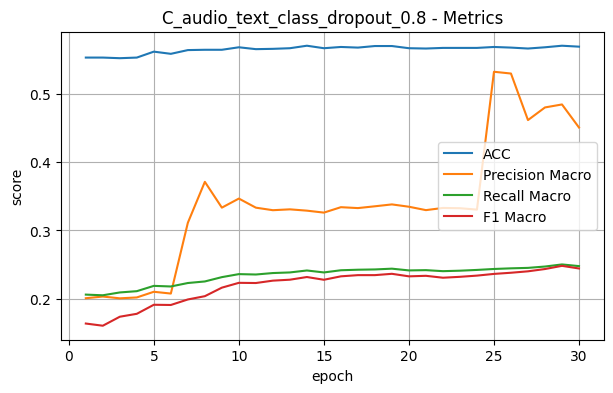

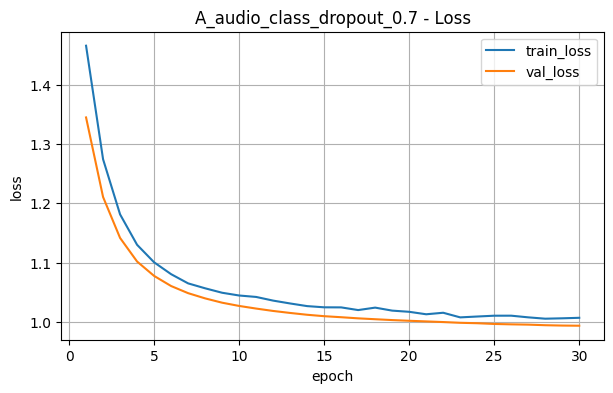

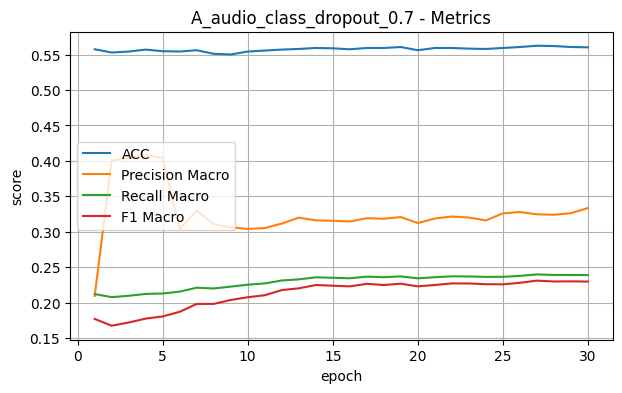

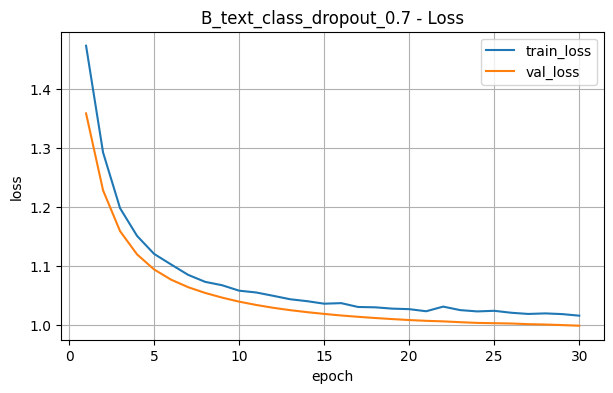

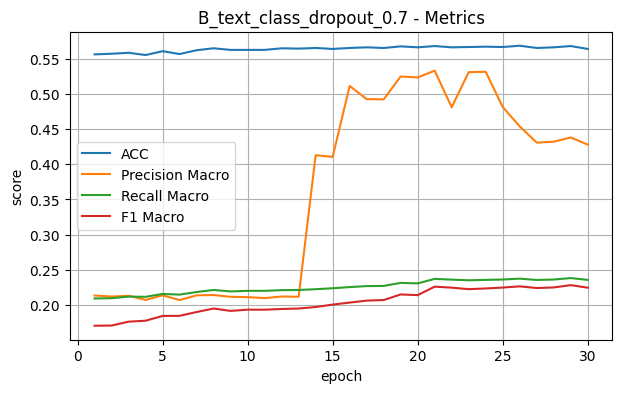

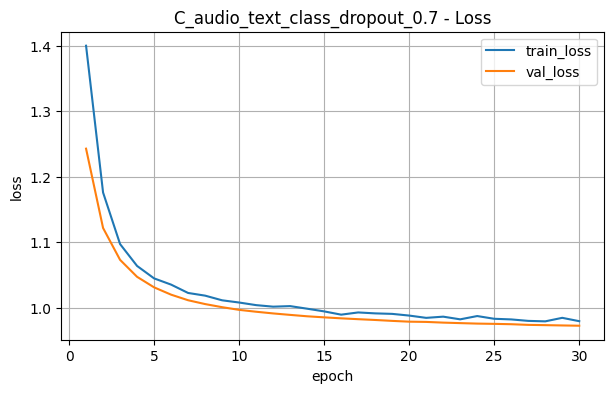

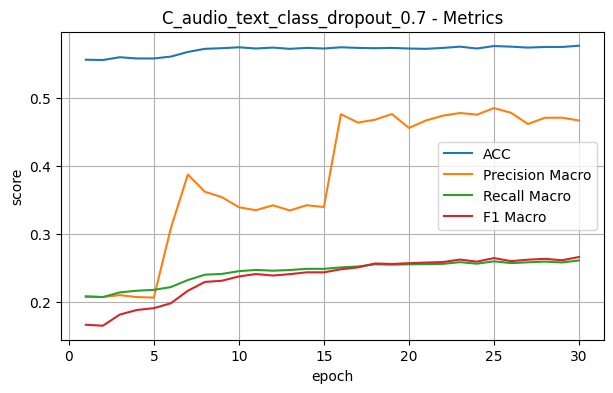

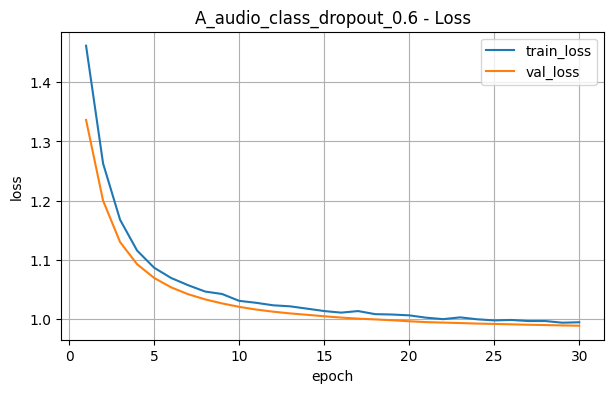

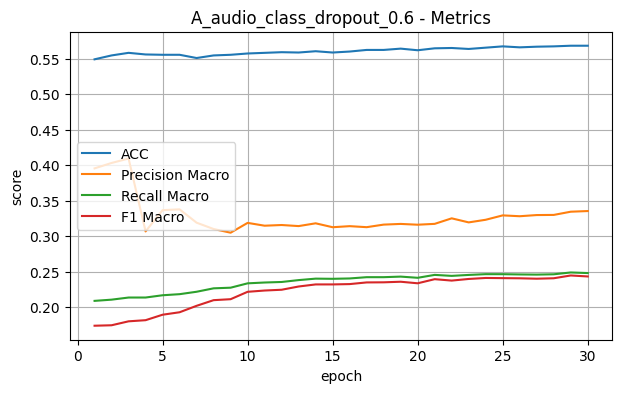

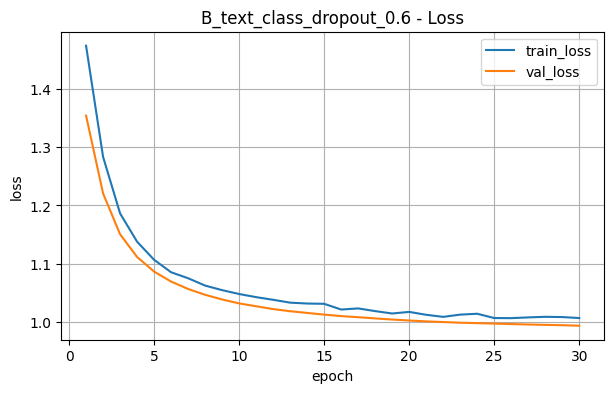

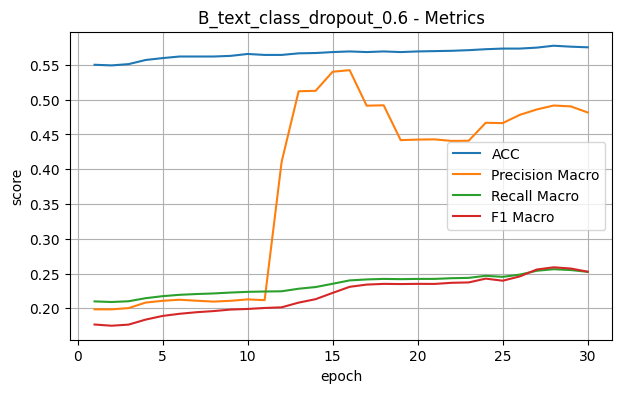

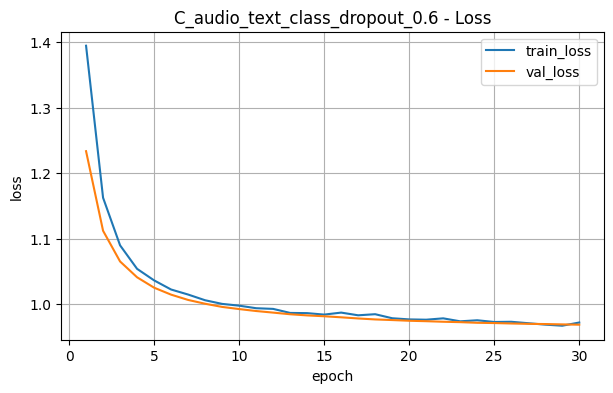

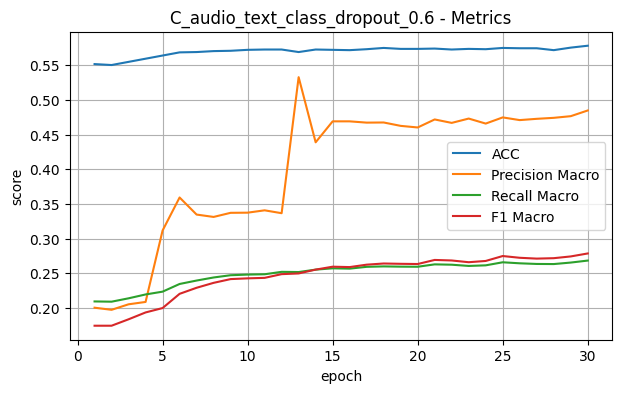

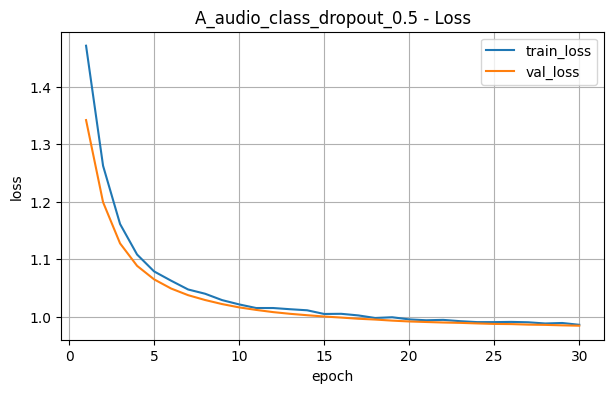

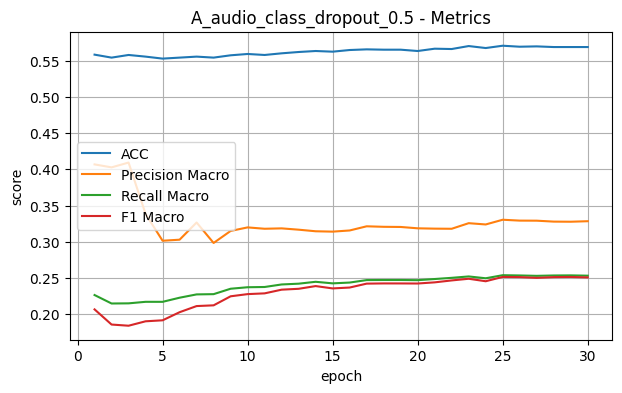

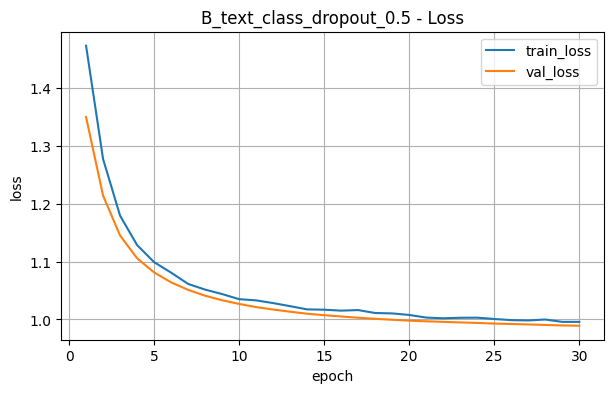

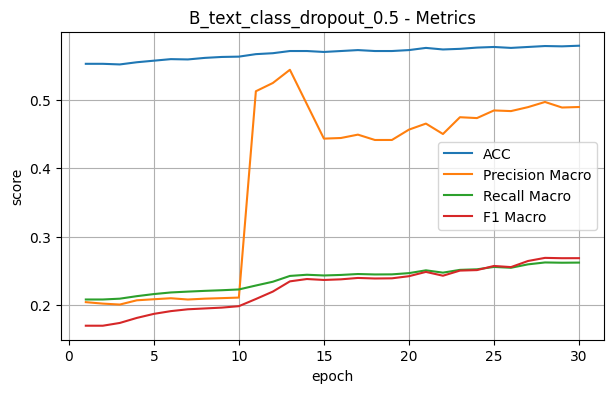

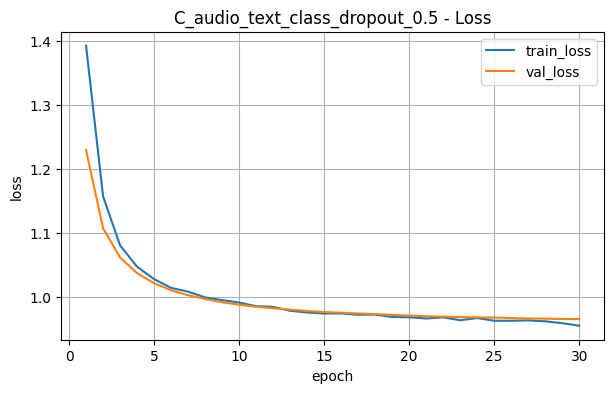

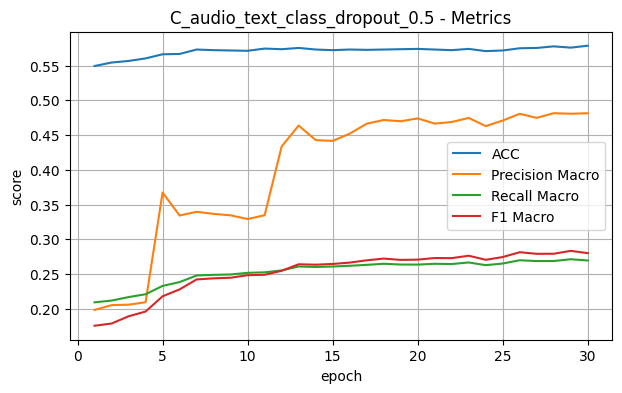

In [34]:
# =========================
# 10. graph
# =========================
for exp_name, res in results.items():
    hist = res["history"]

    plt.figure(figsize=(7, 4))
    plt.plot(hist["epoch"], hist["train_loss"], label="train_loss")
    plt.plot(hist["epoch"], hist["val_loss"], label="val_loss")
    plt.title(f"{exp_name} - Loss")
    plt.xlabel("epoch")
    plt.ylabel("loss")
    plt.legend()
    plt.grid(True)
    plt.show()

    plt.figure(figsize=(7, 4))
    plt.plot(hist["epoch"], hist["acc"], label="ACC")
    plt.plot(hist["epoch"], hist["precision_macro"], label="Precision Macro")
    plt.plot(hist["epoch"], hist["recall_macro"], label="Recall Macro")
    plt.plot(hist["epoch"], hist["f1_macro"], label="F1 Macro")
    plt.title(f"{exp_name} - Metrics")
    plt.xlabel("epoch")
    plt.ylabel("score")
    plt.legend()
    plt.grid(True)
    plt.show()

## 11. prediction 분석

가장 좋은 실험을 기준으로 classification report와 confusion matrix를 확인합니다.

Best experiment: C_audio_text_class_dropout_0.5

Classification Report
              precision    recall  f1-score   support

           0     0.0000    0.0000    0.0000        21
           1     0.7333    0.0733    0.1333       150
           2     0.4813    0.2744    0.3495       656
           3     0.5940    0.8669    0.7050      1210
           4     0.5946    0.1419    0.2292       155

    accuracy                         0.5757      2192
   macro avg     0.4806    0.2713    0.2834      2192
weighted avg     0.5642    0.5757    0.5191      2192

Confusion Matrix (counts)
[[   0    0   10   11    0]
 [   0   11   39  100    0]
 [   0    0  180  476    0]
 [   0    4  142 1049   15]
 [   0    0    3  130   22]]
Normalized Confusion Matrix (row-wise, 0~1)
[[0.     0.     0.4762 0.5238 0.    ]
 [0.     0.0733 0.26   0.6667 0.    ]
 [0.     0.     0.2744 0.7256 0.    ]
 [0.     0.0033 0.1174 0.8669 0.0124]
 [0.     0.     0.0194 0.8387 0.1419]]


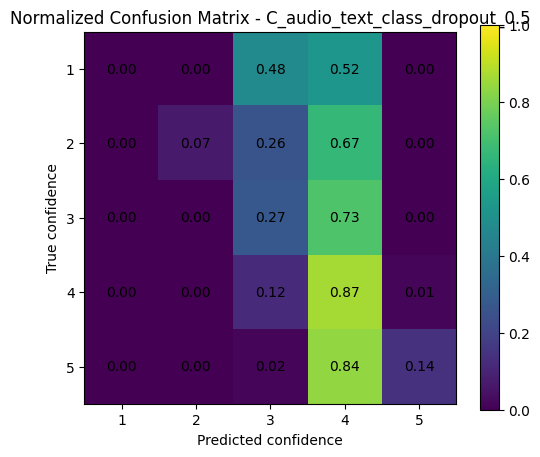

,y_true,y_pred,correct,pred_confidence_prob
0,4,2,False,0.426649
1,4,4,True,0.676703
2,3,3,True,0.586204
3,4,4,True,0.456973
4,2,2,True,0.406208


prediction accuracy: 0.5757299270072993


In [35]:
# =========================
# 11. prediction 분석
# =========================
best_exp = summary_df.iloc[0]["experiment"]
best = results[best_exp]

print("Best experiment:", best_exp)
y_true = best["predictions"]["y_true"]
y_pred = best["predictions"]["y_pred"]
y_prob = best["predictions"]["y_prob"]

print("\nClassification Report")
print(classification_report(y_true, y_pred, digits=4, zero_division=0))

cm = confusion_matrix(y_true, y_pred, labels=[0, 1, 2, 3, 4])
cm_norm = cm.astype(np.float32) / np.maximum(cm.sum(axis=1, keepdims=True), 1)
print("Confusion Matrix (counts)")
print(cm)
print("Normalized Confusion Matrix (row-wise, 0~1)")
print(np.round(cm_norm, 4))

plt.figure(figsize=(6, 5))
plt.imshow(cm_norm, vmin=0, vmax=1)
plt.title(f"Normalized Confusion Matrix - {best_exp}")
plt.xlabel("Predicted confidence")
plt.ylabel("True confidence")
plt.xticks(range(5), [1, 2, 3, 4, 5])
plt.yticks(range(5), [1, 2, 3, 4, 5])
for i in range(cm_norm.shape[0]):
    for j in range(cm_norm.shape[1]):
        plt.text(j, i, f"{cm_norm[i, j]:.2f}", ha="center", va="center")
plt.colorbar()
plt.show()

pred_df = pd.DataFrame({
    "y_true": y_true + 1,
    "y_pred": y_pred + 1,
    "correct": y_true == y_pred,
    "pred_confidence_prob": y_prob.max(axis=1),
})
display(pred_df.head())
print("prediction accuracy:", pred_df["correct"].mean())

## 12. 결과 저장

summary, best prediction, best model을 저장합니다.

In [36]:
# =========================
# 12. 결과 저장
# =========================
best_exp = summary_df.iloc[0]["experiment"]
best = results[best_exp]

# prediction 저장
pred_df = pd.DataFrame({
    "y_true": best["predictions"]["y_true"],
    "y_pred": best["predictions"]["y_pred"],
    "correct": best["predictions"]["y_true"] == best["predictions"]["y_pred"],
    "pred_confidence_prob": best["predictions"]["y_prob"].max(axis=1),
})
pred_path = os.path.join(OUTPUT_DIR, f"best_predictions_{best_exp}.csv")
pred_df.to_csv(pred_path, index=False)

# 모델 저장
model_path = os.path.join(OUTPUT_DIR, f"best_model_{best_exp}.pt")
torch.save({
    "experiment": best_exp,
    "base_experiment": best["base_experiment"],
    "dropout": best["dropout"],
    "model_state_dict": best["model"].state_dict(),
    "metrics": best["metrics"],
    "class_mapping": {int(i): cls for i, cls in enumerate(class_encoder.classes_)},
    "config": {
        "input_dim": features[best["base_experiment"]].shape[1],
        "num_outputs": 5,
        "dropout_values": DROPOUT_VALUES,
        "selected_dropout": best["dropout"],
        "batch_size": BATCH_SIZE,
        "epochs": EPOCHS,
        "lr": LR,
        "weight_decay": WEIGHT_DECAY,
    }
}, model_path)

# 전체 실험 history 저장
history_json = {}
for exp_name, res in results.items():
    history_json[exp_name] = {
        "base_experiment": res["base_experiment"],
        "dropout": res["dropout"],
        "history": res["history"],
    }

history_path = os.path.join(OUTPUT_DIR, "history_dropout_sweep.json")
with open(history_path, "w", encoding="utf-8") as f:
    json.dump(history_json, f, ensure_ascii=False, indent=2)

print("saved summary:", summary_path)
print("saved predictions:", pred_path)
print("saved model:", model_path)
print("saved history:", history_path)

saved summary: c:\Users\solok\Desktop\Dcase baseline\outputs\confidence_mlp_outputs\summary_metrics_dropout_sweep.csv
saved predictions: c:\Users\solok\Desktop\Dcase baseline\outputs\confidence_mlp_outputs\best_predictions_C_audio_text_class_dropout_0.5.csv
saved model: c:\Users\solok\Desktop\Dcase baseline\outputs\confidence_mlp_outputs\best_model_C_audio_text_class_dropout_0.5.pt
saved history: c:\Users\solok\Desktop\Dcase baseline\outputs\confidence_mlp_outputs\history_dropout_sweep.json


## 추가 확인이 필요한 코드/정보

이 노트북을 실제 데이터에 바로 맞추려면 아래 정보가 필요할 수 있습니다.

1. `metadata.csv`의 실제 컬럼명
   - sound id 컬럼명
   - 23개 class 컬럼명
   - confidence 컬럼명
2. confidence label 범위
   - 1~5인지
   - 0~4인지
3. `.npy` 파일명 규칙
   - `{sound_id}.npy`인지
   - prefix/suffix가 붙는지
4. class가 문자열인지 숫자인지
5. audio/text embedding shape이 항상 `(512,)`인지, 혹은 `(1, 512)`인지

현재 코드는 가장 일반적인 규칙인 `{sound_id}.npy`, confidence 1~5, embedding reshape(-1)을 기준으로 작성되어 있습니다.